### I. Hello world graph

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

### Define graph state.

In [3]:
class InputState(TypedDict):
    user_input: str

class OutputState(TypedDict):
    graph_output: str

class OverallState(TypedDict):
    foo: str
    user_input: str
    graph_output: str

class PrivateState(TypedDict):
    bar: str

def node_1(state: InputState) -> OverallState:
    # Write to OverallState
    return {"foo": state["user_input"] + " name"}

def node_2(state: OverallState) -> PrivateState:
    # Read from OverallState, write to PrivateState
    return {"bar": state["foo"] + " is"}

def node_3(state: PrivateState) -> OutputState:
    # Read from PrivateState, write to OutputState
    return {"graph_output": state["bar"] + " Lance"}

builder = StateGraph(OverallState,input_schema=InputState,output_schema=OutputState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)
graph = builder.compile()


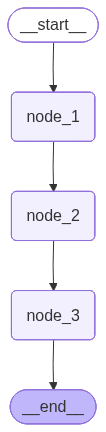

In [4]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
iterator = graph.stream({"user_input":"My"})
# {'graph_output': 'My name is Lance'}

for r in iterator:
    print(r)

{'node_1': {'foo': 'My name'}}
{'node_2': {'bar': 'My name is'}}
{'node_3': {'graph_output': 'My name is Lance'}}


### Use BaseModel

In [ ]:
from pydantic import BaseModel

class InputState(BaseModel):
    user_input: str

class OutputState(BaseModel):
    graph_output: str

class OverallState(BaseModel):
    foo: str
    user_input: str
    graph_output: str

class PrivateState(BaseModel):
    bar: str

def node_1(state: InputState) -> OverallState:
    # Write to OverallState
    print('>>>>',type(state))
    return {"foo": state["user_input"] + " name"}

def node_2(state: OverallState) -> PrivateState:
    # Read from OverallState, write to PrivateState
    return {"bar": state["foo"] + " is"}

def node_3(state: PrivateState) -> OutputState:
    # Read from PrivateState, write to OutputState
    return {"graph_output": state["bar"] + " Lance"}

builder = StateGraph(OverallState,input_schema=InputState,output_schema=OutputState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)
graph = builder.compile()


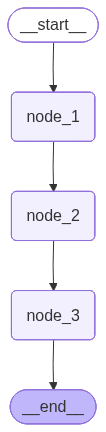

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"user_input":"My"})
# {'graph_output': 'My name is Lance'}

>>>> user_input='My'


TypeError: 'InputState' object is not subscriptable

In [15]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from pydantic import BaseModel

# The overall state of the graph (this is the public state shared across nodes)
class OverallState(BaseModel):
    a: str

def node(state: OverallState):
    return {"a": "goodbye"}

# Build the state graph
builder = StateGraph(OverallState)
builder.add_node(node)  # node_1 is the first node
builder.add_edge(START, "node")  # Start the graph with node_1
builder.add_edge("node", END)  # End the graph after node_1
graph = builder.compile()

# Test the graph with a valid input
graph.invoke({"a": "hello"})

{'a': 'goodbye'}